# Methodikbeispiel: Raster und Route

Die Karten verwenden einen 1,2 × 1,2 km großen Ausschnitt um **47,089273° N, 15,440171° E**. Die graue Verwaltungsgrundkarte stammt von [basemap.at](https://basemap.at); darüber liegen das 100-m-Bevölkerungsraster und in der zweiten Abbildung eine Route im lokalen Straßennetz.

In [1]:
from collections import defaultdict
from pathlib import Path
import heapq
import math
import sys

import contextily as cx
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pyogrio
from matplotlib.colors import Normalize, to_rgba
from matplotlib.patches import Patch
from matplotlib.ticker import FuncFormatter
from scipy.spatial import cKDTree
from shapely import concave_hull
from shapely.geometry import LineString, MultiPoint, Point, box
from xyzservices import TileProvider


def find_project_root(start=Path.cwd().resolve()):
    for candidate in (start, *start.parents):
        if (candidate / 'FIG' / 'plotting' / 'apa7.py').exists():
            return candidate
    raise FileNotFoundError('Projektwurzel wurde nicht gefunden.')


ROOT = find_project_root()
sys.path.insert(0, str(ROOT / 'FIG'))

from plotting.apa7 import (
    set_apa7_style,
    new_figure,
    save_apa7,
    HIST_KWARGS,
)

set_apa7_style()

# plt.rcParams.update({
#     'font.family': 'DejaVu Sans',
#     'font.size': 9,
#     'axes.titlesize': 11,
#     'figure.dpi': 120,
# })

In [2]:
OUTPUT_DIR = ROOT / 'FIG' / 'methodology'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
RASTER_PATH = ROOT / 'ANAL' / 'data' / 'raster_100m_styria.geoparquet'
ROADS_PATH = ROOT / 'OGD' / 'GIP' / '2025.osm.pbf'

start_lon, start_lat = 15.440171009255982, 47.089273274870145
end_lon, end_lat = 15.44425219808648, 47.0925339094921
points_wgs84 = gpd.GeoSeries(
    [Point(start_lon, start_lat), Point(end_lon, end_lat)], crs='EPSG:4326'
)
start_point, end_point = points_wgs84.to_crs('EPSG:3035')

half_width_m = 600
analysis_radius_m = 1_600
initial_bbox = (start_point.x-analysis_radius_m, start_point.y-analysis_radius_m,
                start_point.x+analysis_radius_m, start_point.y+analysis_radius_m)
analysis_raster = gpd.read_parquet(RASTER_PATH, filters=[
    ('centroid_x', '>=', initial_bbox[0]),
    ('centroid_x', '<=', initial_bbox[2]),
    ('centroid_y', '>=', initial_bbox[1]),
    ('centroid_y', '<=', initial_bbox[3]),
])
selected = analysis_raster.loc[analysis_raster.geometry.intersects(start_point)]
if selected.empty:
    selected = analysis_raster.iloc[[analysis_raster.geometry.centroid.distance(start_point).argmin()]]
selected_cell = selected.iloc[[0]]
centre = selected_cell.geometry.iloc[0].centroid
extent = (centre.x-half_width_m, centre.x+half_width_m,
          centre.y-half_width_m, centre.y+half_width_m)
raster = analysis_raster.cx[extent[0]:extent[1], extent[2]:extent[3]].copy()
print(f'Ausgewählte Zelle: {selected_cell.iloc[0]["grid_id"]}')

Ausgewählte Zelle: AT_CRS3035RES100mN2679100E4733900


In [3]:
BASEMAP_AT_GRAY = TileProvider(
    name='basemap.at Grau',
    url='https://maps.wien.gv.at/basemap/bmapgrau/normal/google3857/{z}/{y}/{x}.png',
    attribution='basemap.at',
    max_zoom=20,
)

population = raster['population_2025'].fillna(0).clip(lower=0)
upper_limit = max(1.0, float(population.quantile(0.99)))
normalisation = Normalize(vmin=0, vmax=upper_limit)
colour_map = plt.get_cmap('YlOrRd')
cell_colours = colour_map(normalisation(population.clip(upper=upper_limit)))
cell_colours[:, 3] = np.where(population.to_numpy() > 0, 0.55, 0.08)

def draw_raster_map(show_population_labels=False, highlight_selected_cell=True):
    fig, ax = plt.subplots(figsize=(8.2, 8.2))
    ax.set_xlim(extent[0], extent[1])
    ax.set_ylim(extent[2], extent[3])
    cx.add_basemap(
        ax, crs=raster.crs.to_string(), source=BASEMAP_AT_GRAY,
        zoom=16, attribution_size=5,
    )
    raster.plot(
        ax=ax, facecolor=cell_colours, edgecolor='#707070',
        linewidth=0.55, zorder=3,
    )
    if highlight_selected_cell:
        selected_cell.boundary.plot(ax=ax, color='#005a9c', linewidth=2.0, zorder=5)
    if show_population_labels:
        for cell in raster.itertuples():
            cell_centre = cell.geometry.centroid
            raw_value = getattr(cell, 'population_2025', 0)
            value = 0 if pd.isna(raw_value) else int(round(max(0, raw_value)))
            ax.text(
                cell_centre.x, cell_centre.y, str(value),
                ha='center', va='center', fontsize=7, color='black', zorder=6,
                # bbox={'facecolor': 'white', 'edgecolor': 'none', 'alpha': 0.55, 'pad': 0.25},
            )
    colour_bar = fig.colorbar(
        plt.cm.ScalarMappable(norm=normalisation, cmap=colour_map),
        ax=ax, fraction=0.038, pad=0.02, shrink=0.78,
    )
    colour_bar.set_label('Bevölkerung 2025 je 100-m-Zelle')
    colour_bar.ax.yaxis.set_major_formatter(
        FuncFormatter(lambda value, _: f'{value:,.0f}'.replace(',', '.'))
    )
    ax.set_axis_off()
    fig.tight_layout()
    return fig, ax

def draw_raster_grid_map(highlight_selected_cell=True):
    fig, ax = plt.subplots(figsize=(8.2, 8.2))
    ax.set_xlim(extent[0], extent[1])
    ax.set_ylim(extent[2], extent[3])
    cx.add_basemap(
        ax, crs=raster.crs.to_string(), source=BASEMAP_AT_GRAY,
        zoom=16, attribution_size=5,
    )
    raster.boundary.plot(ax=ax, color='#707070', linewidth=0.55, zorder=3)
    if highlight_selected_cell:
        selected_cell.boundary.plot(ax=ax, color='#005a9c', linewidth=2.0, zorder=5)
    ax.set_axis_off()
    fig.tight_layout()
    return fig, ax

**Abbildung 0**  
*100-m-Raster ohne Bevölkerungsgewichtung*

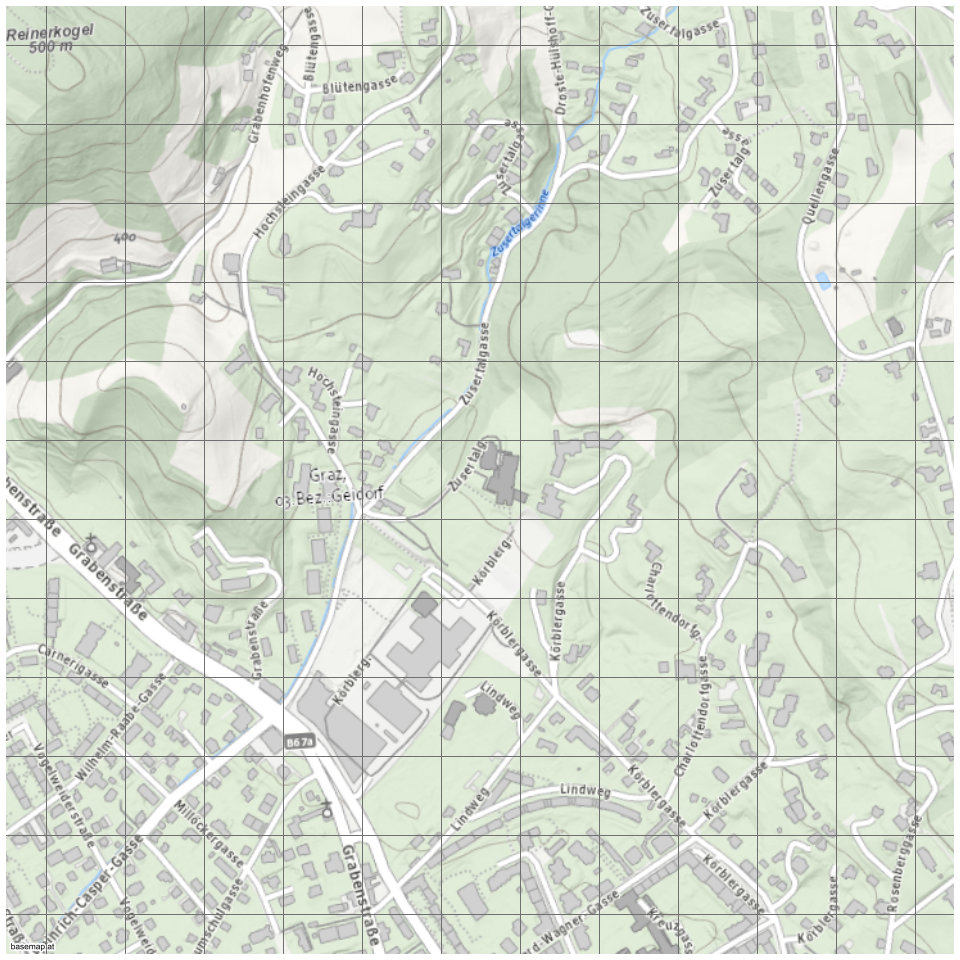

In [4]:
fig, ax = draw_raster_grid_map(highlight_selected_cell=False)
fig.savefig(OUTPUT_DIR / 'figure_0_100m_raster_grid.png', dpi=300, bbox_inches='tight', facecolor='white')
fig.savefig(OUTPUT_DIR / 'figure_0_100m_raster_grid.svg', bbox_inches='tight', facecolor='white')
plt.show()

**Abbildung 1**  
*100-m-Raster am Beispielstandort*

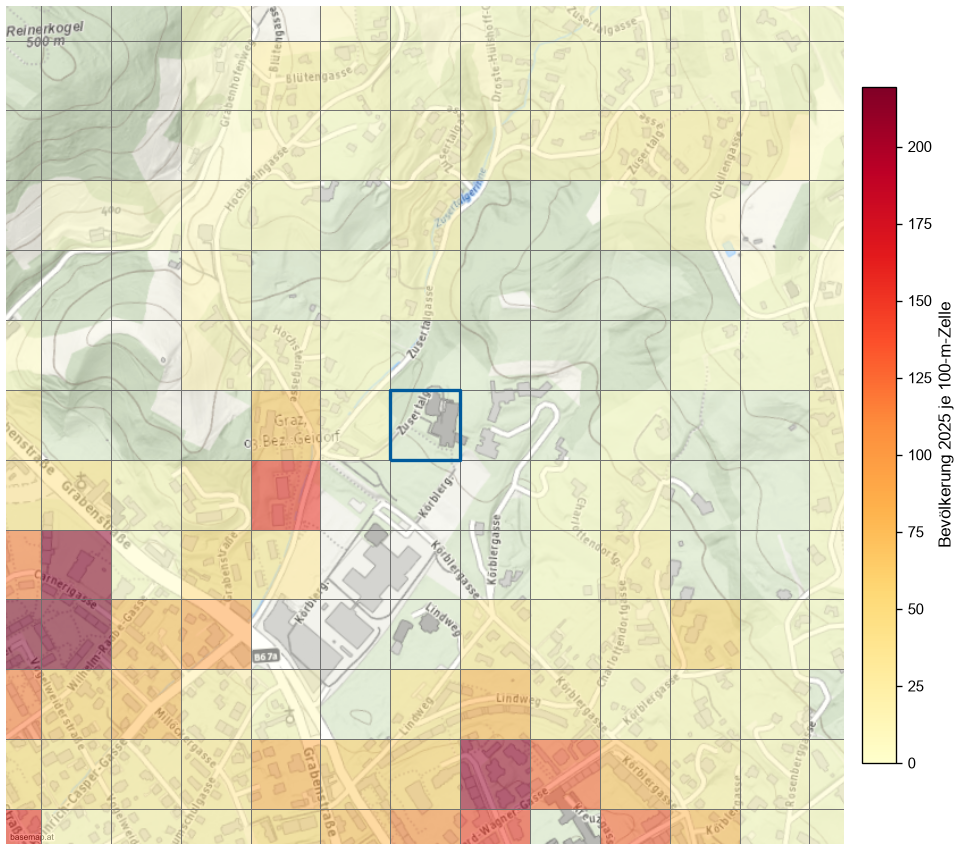

In [5]:
fig, ax = draw_raster_map()
fig.savefig(OUTPUT_DIR / 'figure_1_100m_raster_example.png', dpi=300, bbox_inches='tight', facecolor='white')
fig.savefig(OUTPUT_DIR / 'figure_1_100m_raster_example.svg', bbox_inches='tight', facecolor='white')
plt.show()

**Abbildung 1b**  
*100-m-Raster mit Bevölkerungswerten je Zelle*

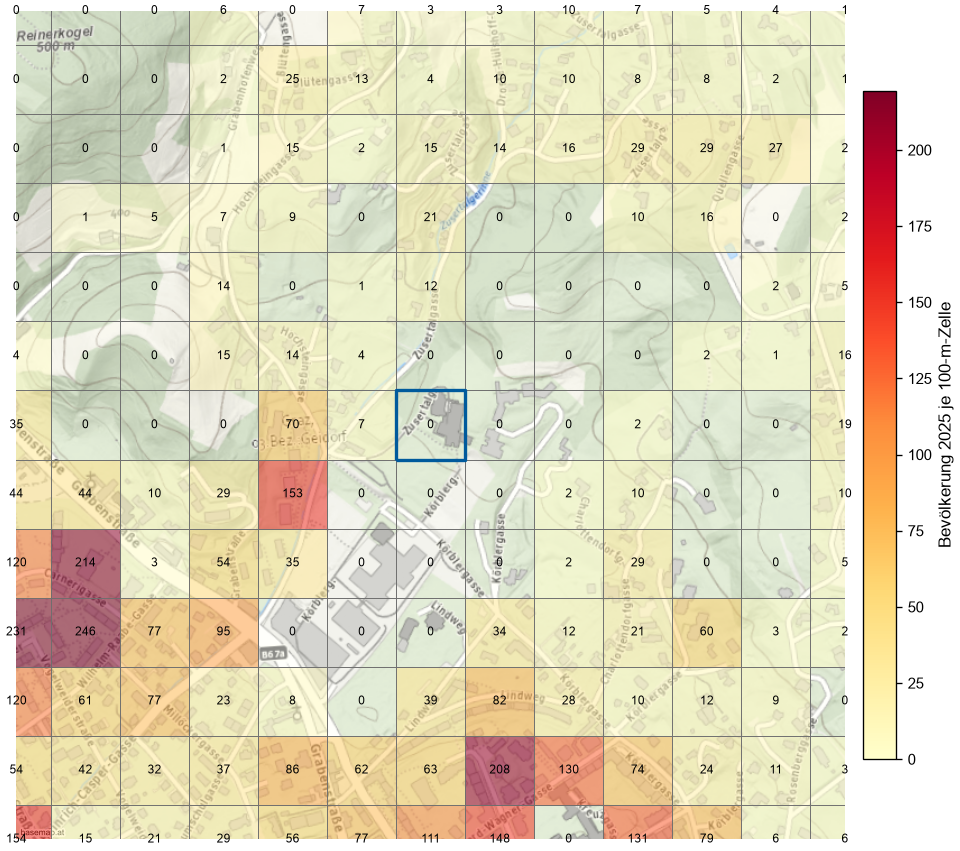

In [6]:
fig, ax = draw_raster_map(show_population_labels=True)
fig.savefig(OUTPUT_DIR / 'figure_1b_100m_raster_population_labels.png', dpi=300, bbox_inches='tight', facecolor='white')
fig.savefig(OUTPUT_DIR / 'figure_1b_100m_raster_population_labels.svg', bbox_inches='tight', facecolor='white')
plt.show()

**Abbildung 2**  
*Route im 100-m-Raster*

In [7]:
search_area = gpd.GeoSeries(
    [box(extent[0]-1_000, extent[2]-1_000, extent[1]+1_000, extent[3]+1_000)],
    crs=raster.crs,
).to_crs('EPSG:4326').total_bounds
roads = pyogrio.read_dataframe(
    ROADS_PATH, layer='lines', bbox=tuple(search_area)
).to_crs(raster.crs)
roads = roads.loc[roads['highway'].notna()].copy()

CAR_SPEED_KMH = {
    'motorway': 100, 'motorway_link': 50, 'trunk': 80, 'trunk_link': 40,
    'primary': 50, 'primary_link': 35, 'secondary': 45,
    'tertiary': 40, 'residential': 30, 'unclassified': 30,
    'living_street': 10, 'service': 15, 'track': 10,
}

def solve_route(road_frame, speed_function, connector_speed_kmh):
    adjacency = defaultdict(list)
    nodes = {}
    for row in road_frame[['highway', 'geometry']].itertuples(index=False):
        geometry = row.geometry
        if geometry is None or geometry.is_empty:
            continue
        parts = [geometry] if geometry.geom_type == 'LineString' else geometry.geoms
        for part in parts:
            coordinates = list(part.coords)
            for first, second in zip(coordinates[:-1], coordinates[1:]):
                first_key = (round(first[0], 2), round(first[1], 2))
                second_key = (round(second[0], 2), round(second[1], 2))
                length_m = math.hypot(second[0]-first[0], second[1]-first[1])
                if length_m == 0:
                    continue
                minutes = length_m / (speed_function(row.highway) * 1_000 / 60)
                nodes[first_key] = first_key
                nodes[second_key] = second_key
                adjacency[first_key].append((second_key, length_m, minutes))
                adjacency[second_key].append((first_key, length_m, minutes))

    node_keys = list(nodes)
    node_tree = cKDTree(np.asarray(node_keys))
    start_node = node_keys[int(node_tree.query([start_point.x, start_point.y])[1])]
    end_node = node_keys[int(node_tree.query([end_point.x, end_point.y])[1])]
    start_connector = math.hypot(start_point.x-start_node[0], start_point.y-start_node[1])
    end_connector = math.hypot(end_point.x-end_node[0], end_point.y-end_node[1])

    travel_times = {start_node: start_connector / (connector_speed_kmh * 1_000 / 60)}
    previous = {}
    queue = [(travel_times[start_node], start_node)]
    while queue:
        time_so_far, node = heapq.heappop(queue)
        if time_so_far != travel_times.get(node):
            continue
        for neighbour, edge_length, edge_minutes in adjacency[node]:
            candidate = time_so_far + edge_minutes
            if candidate < travel_times.get(neighbour, float('inf')):
                travel_times[neighbour] = candidate
                previous[neighbour] = node
                heapq.heappush(queue, (candidate, neighbour))
    if end_node not in travel_times:
        raise RuntimeError('Zwischen Start und Ziel wurde keine Netzroute gefunden.')

    path_nodes = [end_node]
    while path_nodes[-1] != start_node:
        path_nodes.append(previous[path_nodes[-1]])
    path_nodes.reverse()
    geometry = LineString(
        [(start_point.x, start_point.y), *path_nodes, (end_point.x, end_point.y)]
    )
    total_minutes = travel_times[end_node] + end_connector / (connector_speed_kmh * 1_000 / 60)
    return geometry, geometry.length, total_minutes, travel_times, node_keys

car_excluded = {'footway', 'path', 'cycleway', 'steps', 'pedestrian',
                'bridleway', 'corridor', 'proposed', 'construction'}
walk_excluded = {'motorway', 'motorway_link', 'trunk', 'trunk_link',
                 'proposed', 'construction'}
car_roads = roads.loc[~roads['highway'].isin(car_excluded)]
walk_roads = roads.loc[~roads['highway'].isin(walk_excluded)]
car_route, car_length_m, car_minutes, _, _ = solve_route(
    car_roads, lambda road_class: CAR_SPEED_KMH.get(road_class, 25), 15
)
walking_route, walking_length_m, walking_minutes, walking_times, walking_nodes = solve_route(
    walk_roads, lambda road_class: 5, 5
)

route_summary = pd.DataFrame({
    'Verkehrsart': ['Pkw', 'Zu Fuß'],
    'Länge (m)': [
        f'{car_length_m:,.0f}'.replace(',', '.'),
        f'{walking_length_m:,.0f}'.replace(',', '.'),
    ],
    'Fahrzeit (Min.)': [
        f'{car_minutes:.1f}'.replace('.', ','),
        f'{walking_minutes:.1f}'.replace('.', ','),
    ],
})
route_summary.style.hide(axis='index')

Verkehrsart,Länge (m),Fahrzeit (Min.)
Pkw,1.098,"2,6"
Zu Fuß,1.098,"13,2"


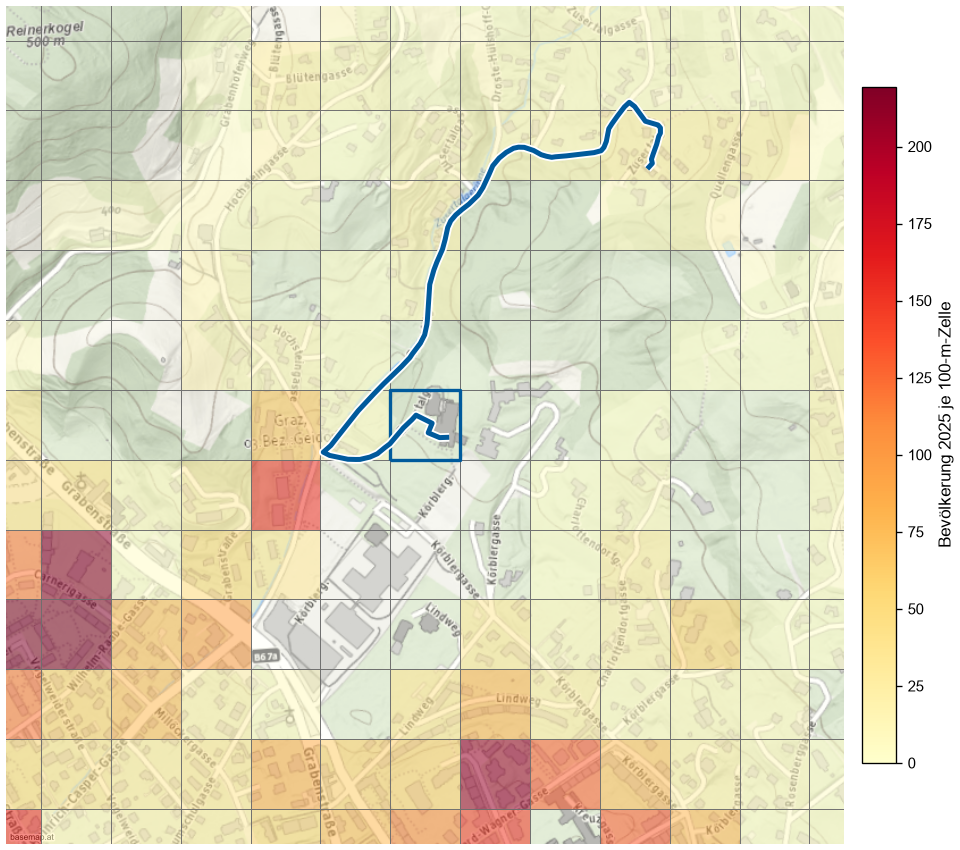

In [8]:
fig, ax = draw_raster_map()
route_layer = gpd.GeoSeries([car_route], crs=raster.crs)
route_layer.plot(ax=ax, color='white', linewidth=5.2, zorder=6)
route_layer.plot(ax=ax, color='#005a9c', linewidth=3.0, zorder=7)
fig.savefig(OUTPUT_DIR / 'figure_2_route_example.png', dpi=300, bbox_inches='tight', facecolor='white')
fig.savefig(OUTPUT_DIR / 'figure_2_route_example.svg', bbox_inches='tight', facecolor='white')
plt.show()

**Abbildung 3**  
*Fußwegisochronen im 100-m-Raster*

In [9]:
isochrone_levels = [5, 10, 15]
isochrone_polygons = {}
previous_polygon = None
for level in isochrone_levels:
    reachable = [node for node, minutes in walking_times.items() if minutes <= level]
    if len(reachable) < 3:
        raise RuntimeError(f'Zu wenige erreichbare Netzknoten für {level} Minuten.')
    polygon = (concave_hull(MultiPoint(reachable), ratio=0.45, allow_holes=False)
               .buffer(55, join_style='round').buffer(-15, join_style='round').simplify(8))
    if previous_polygon is not None:
        polygon = polygon.union(previous_polygon)
    isochrone_polygons[level] = polygon
    previous_polygon = polygon

population_centroids = analysis_raster.geometry.centroid
isochrone_summary = pd.DataFrame({
    'Gehzeit (Min.)': isochrone_levels,
    'Erreichbare Bevölkerung': [
        round(analysis_raster.loc[population_centroids.within(isochrone_polygons[level]),
                                  'population_2025'].fillna(0).sum())
        for level in isochrone_levels
    ],
})

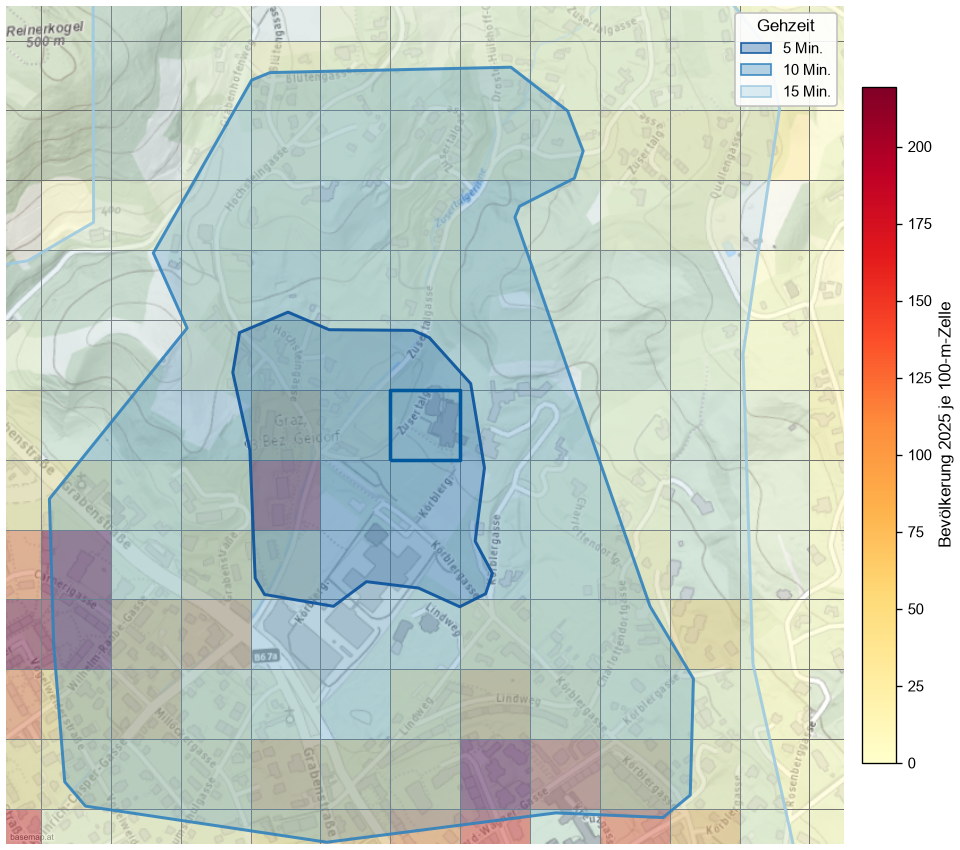

In [10]:
fig, ax = draw_raster_map()
isochrone_colours = {5: '#08519c', 10: '#3182bd', 15: '#9ecae1'}
ISOCHRONE_FILL_ALPHA = 0.22
ISOCHRONE_EDGE_ALPHA = 0.90


def plot_isochrone_polygon(ax, polygon, level, crs, zorder=5):
    colour = isochrone_colours[level]
    gpd.GeoSeries([polygon], crs=crs).plot(
        ax=ax,
        facecolor=to_rgba(colour, ISOCHRONE_FILL_ALPHA),
        edgecolor=to_rgba(colour, ISOCHRONE_EDGE_ALPHA),
        linewidth=1.8,
        zorder=zorder,
    )


for level in reversed(isochrone_levels):
    plot_isochrone_polygon(
        ax, isochrone_polygons[level], level, raster.crs, zorder=5 + (15-level)
    )
selected_cell.boundary.plot(ax=ax, color='#005a9c', linewidth=2.0, zorder=10)
ax.legend(handles=[
    Patch(
        facecolor=to_rgba(isochrone_colours[level], 0.35),
        edgecolor=to_rgba(isochrone_colours[level], ISOCHRONE_EDGE_ALPHA),
        label=f'{level} Min.',
    )
    for level in isochrone_levels
], title='Gehzeit', loc='upper right', frameon=True, framealpha=0.9, edgecolor='#bdbdbd')
fig.savefig(OUTPUT_DIR / 'figure_3_walking_isochrones.png', dpi=300, bbox_inches='tight', facecolor='white')
fig.savefig(OUTPUT_DIR / 'figure_3_walking_isochrones.svg', bbox_inches='tight', facecolor='white')
plt.show()

In [11]:
# Gemeinsamer Kartenausschnitt: alle drei Abbildungen zeigen vollständig
# die 15-Minuten-Isochrone und sind dadurch direkt vergleichbar.
xmin_15, ymin_15, xmax_15, ymax_15 = isochrone_polygons[15].bounds
isochrone_centre_x = (xmin_15 + xmax_15) / 2
isochrone_centre_y = (ymin_15 + ymax_15) / 2
isochrone_half_width = max(xmax_15 - xmin_15, ymax_15 - ymin_15) / 2 + 150
isochrone_extent = (
    isochrone_centre_x - isochrone_half_width,
    isochrone_centre_x + isochrone_half_width,
    isochrone_centre_y - isochrone_half_width,
    isochrone_centre_y + isochrone_half_width,
)
isochrone_raster = analysis_raster.cx[
    isochrone_extent[0]:isochrone_extent[1],
    isochrone_extent[2]:isochrone_extent[3],
].copy()
def draw_labelled_isochrone_map(level):
    polygon = isochrone_polygons[level]
    if level == 15:
        map_extent = isochrone_extent
        map_raster = isochrone_raster
        basemap_zoom = 15
    else:
        map_extent = extent
        map_raster = raster
        basemap_zoom = 16

    map_population = map_raster['population_2025'].fillna(0).clip(lower=0)
    map_cell_colours = colour_map(normalisation(map_population.clip(upper=upper_limit)))
    map_cell_colours[:, 3] = np.where(map_population.to_numpy() > 0, 0.55, 0.08)
    overlap_area = map_raster.geometry.intersection(polygon).area
    labelled_cells = map_raster.loc[overlap_area.gt(0)].copy()

    fig, ax = plt.subplots(figsize=(8.2, 8.2))
    ax.set_xlim(map_extent[0], map_extent[1])
    ax.set_ylim(map_extent[2], map_extent[3])
    cx.add_basemap(
        ax, crs=map_raster.crs.to_string(), source=BASEMAP_AT_GRAY,
        zoom=basemap_zoom, attribution_size=5,
    )
    map_raster.plot(
        ax=ax, facecolor=map_cell_colours, edgecolor='#707070',
        linewidth=0.35, zorder=3,
    )
    plot_isochrone_polygon(ax, polygon, level, map_raster.crs, zorder=5)
    selected_cell.boundary.plot(ax=ax, color='#005a9c', linewidth=2.0, zorder=10)

    for cell in labelled_cells.itertuples():
        cell_centre = cell.geometry.centroid
        raw_value = getattr(cell, 'population_2025', 0)
        value = 0 if pd.isna(raw_value) else int(round(max(0, raw_value)))
        ax.text(
            cell_centre.x, cell_centre.y, str(value),
            ha='center', va='center', fontsize=7, color='black', zorder=11,
        )

    ax.legend(
        handles=[Patch(
            facecolor=to_rgba(isochrone_colours[level], 0.35),
            edgecolor=to_rgba(isochrone_colours[level], ISOCHRONE_EDGE_ALPHA),
            label=f'{level} Min.',
        )],
        title='Gehzeit', loc='upper right', frameon=True,
        framealpha=0.9, edgecolor='#bdbdbd',
    )
    colour_bar = fig.colorbar(
        plt.cm.ScalarMappable(norm=normalisation, cmap=colour_map),
        ax=ax, fraction=0.038, pad=0.02, shrink=0.78,
    )
    colour_bar.set_label('Bevölkerung 2025 je 100-m-Zelle')
    colour_bar.ax.yaxis.set_major_formatter(
        FuncFormatter(lambda value, _: f'{value:,.0f}'.replace(',', '.'))
    )
    ax.set_axis_off()
    fig.tight_layout()
    return fig, ax, labelled_cells


**Abbildung 3b**  
*Bevölkerungswerte in den von der 5-Minuten-Isochrone überlagerten Rasterzellen*

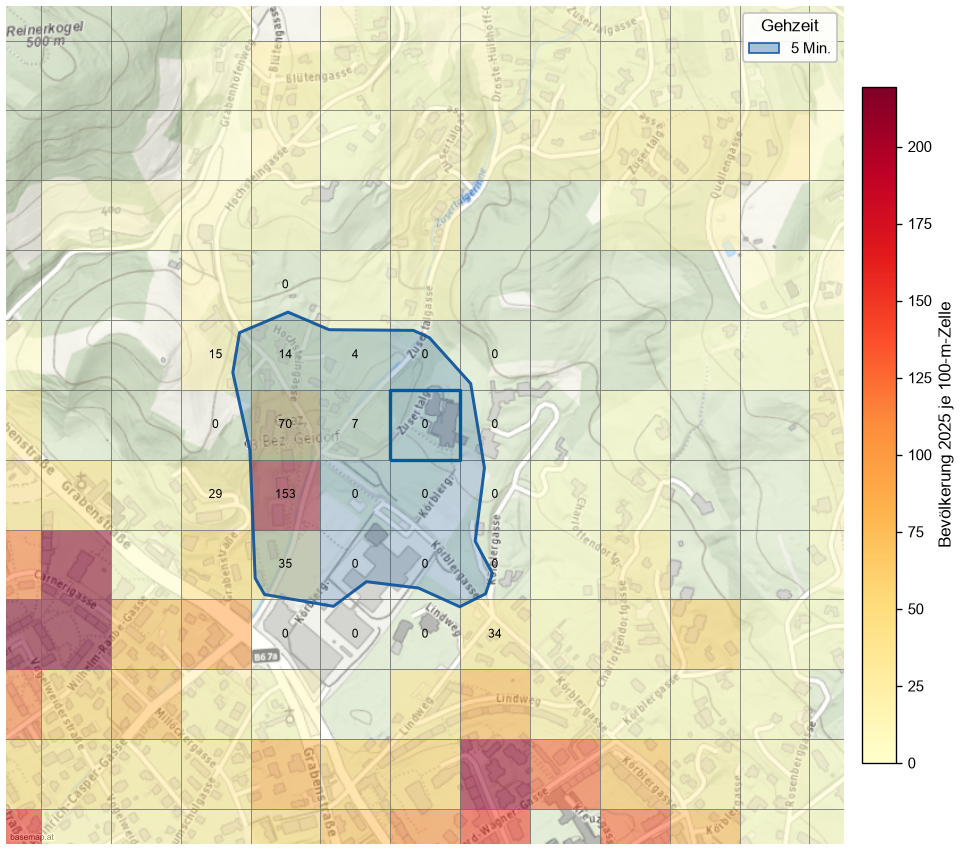

Beschriftete Rasterzellen: 24


In [12]:
fig, ax, labelled_cells_5 = draw_labelled_isochrone_map(5)
fig.savefig(OUTPUT_DIR / 'figure_3b_population_cells_5_minute_isochrone.png', dpi=300, bbox_inches='tight', facecolor='white')
fig.savefig(OUTPUT_DIR / 'figure_3b_population_cells_5_minute_isochrone.svg', bbox_inches='tight', facecolor='white')
plt.show()
print(f'Beschriftete Rasterzellen: {len(labelled_cells_5):,}')

**Abbildung 3c**  
*Bevölkerungswerte in den von der 10-Minuten-Isochrone überlagerten Rasterzellen*

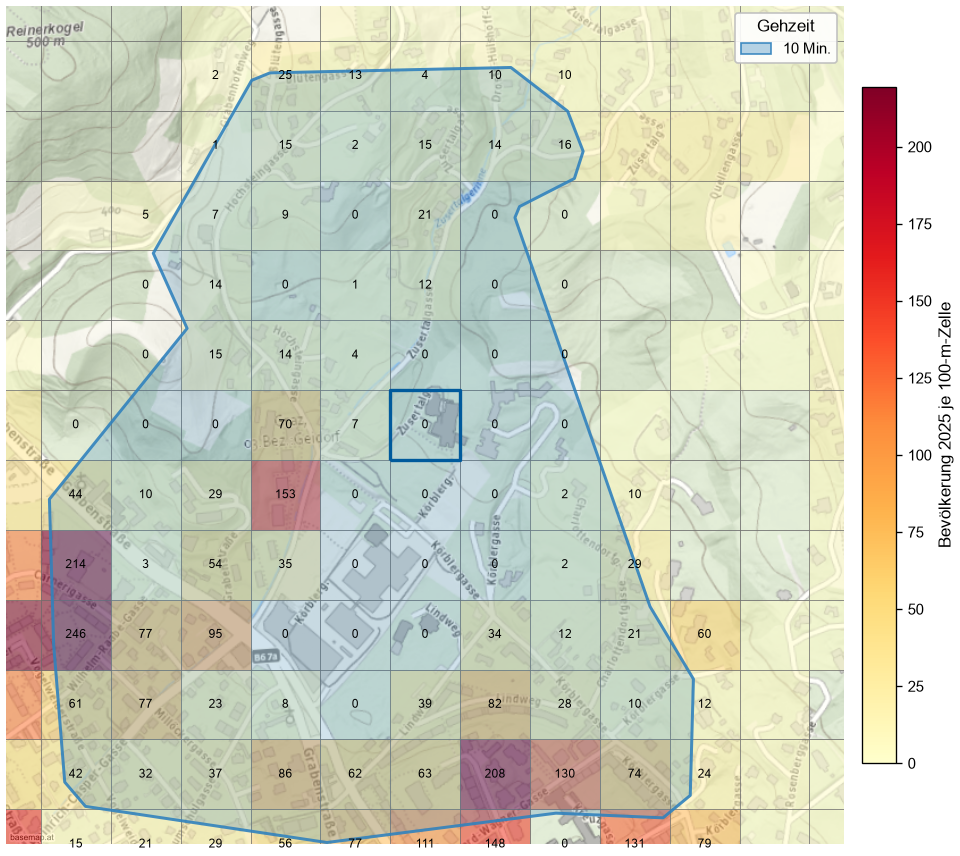

Beschriftete Rasterzellen: 99


In [13]:
fig, ax, labelled_cells_10 = draw_labelled_isochrone_map(10)
fig.savefig(OUTPUT_DIR / 'figure_3c_population_cells_10_minute_isochrone.png', dpi=300, bbox_inches='tight', facecolor='white')
fig.savefig(OUTPUT_DIR / 'figure_3c_population_cells_10_minute_isochrone.svg', bbox_inches='tight', facecolor='white')
plt.show()
print(f'Beschriftete Rasterzellen: {len(labelled_cells_10):,}')

**Abbildung 3d**  
*Bevölkerungswerte in den von der 15-Minuten-Isochrone überlagerten Rasterzellen*

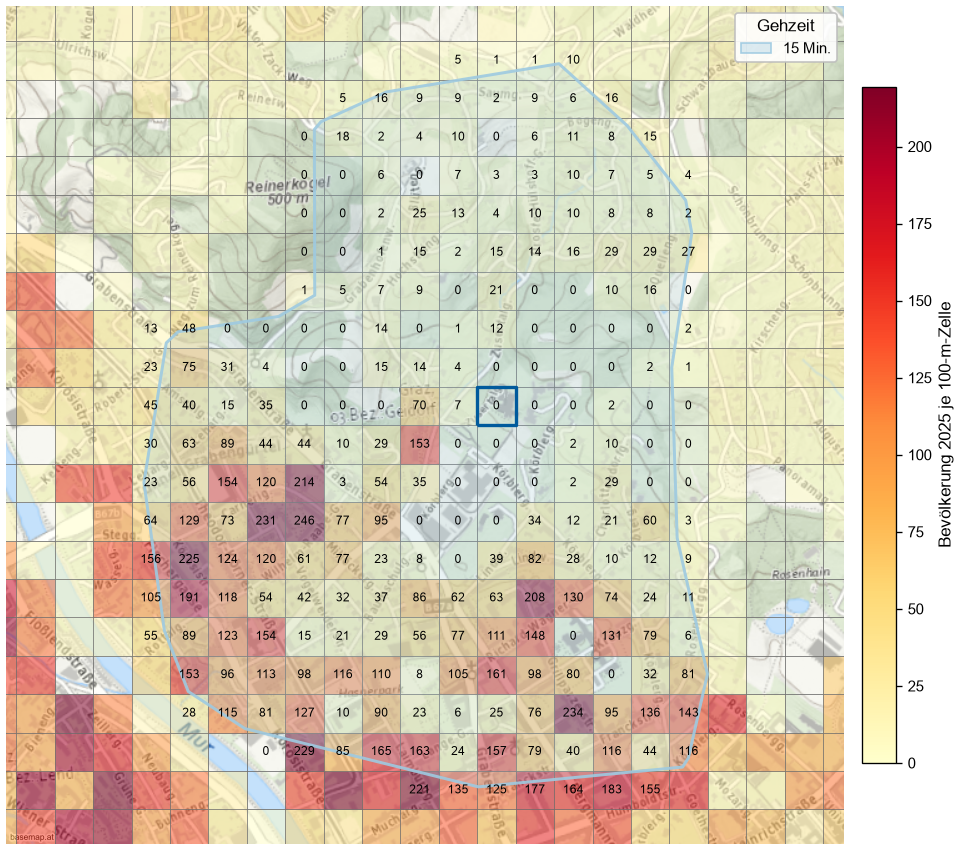

Beschriftete Rasterzellen: 248


In [14]:
fig, ax, labelled_cells_15 = draw_labelled_isochrone_map(15)
fig.savefig(OUTPUT_DIR / 'figure_3d_population_cells_15_minute_isochrone.png', dpi=300, bbox_inches='tight', facecolor='white')
fig.savefig(OUTPUT_DIR / 'figure_3d_population_cells_15_minute_isochrone.svg', bbox_inches='tight', facecolor='white')
plt.show()
print(f'Beschriftete Rasterzellen: {len(labelled_cells_15):,}')

In [15]:
isochrone_output = isochrone_summary.copy()
isochrone_output['Erreichbare Bevölkerung'] = (
    isochrone_output['Erreichbare Bevölkerung'].map(lambda value: f'{value:,.0f}'.replace(',', '.'))
)
isochrone_output.style.hide(axis='index')

Gehzeit (Min.),Erreichbare Bevölkerung
5,283
10,2.411
15,9.348
